In [21]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Colab Notebooks/Zadanie2")

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [23]:
df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

##Wstępne dane

**Obserwacje z etapu pierwszego**

Na podstawie analizy EDA do modelowania wybrano przede wszystkim `Pclass`, `Sex`, `Age`, `Fare` oraz informacje o rodzinie (`SibSp`, `Parch`, `IsAlone`), ponieważ zaobserwowano ich związek z przeżywalnością pasażerów. `Embarked` zakodowano metodą one-hot encoding, natomiast `Name`, `Ticket` i `Cabin` pominięto ze względu na ich małą użyteczność predykcyjną lub dużą liczbę brakujących danych. W przypadku `Age` zastosowano dokładniejsze uzupełnianie braków z uwzględnieniem `Pclass` i `Sex`. Analiza wartości odstających, szczególnie dla `Fare`, pozwoliła lepiej przygotować dane do modelowania. Dodatkowo uwzględniono `IsAlone`, ponieważ sama liczba członków rodziny nie pozwalała jednoznacznie ocenić jej wpływu na przeżycie. Ostateczny zestaw cech został przygotowany z myślą o porównaniu różnych modeli klasyfikacyjnych.

**Przygotowanie danych**

In [24]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['IsAlone'] = (
    (df['SibSp'] == 0) &
    (df['Parch'] == 0)
).astype(int)

df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df = pd.get_dummies(
    df,
    columns=['Embarked'],
    dtype=int
)

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,IsAlone,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,0,1,0,0
3,1,3,1,26.0,0,0,7.9250,1,0,0,1
4,1,1,1,35.0,1,0,53.1000,0,0,0,1
5,0,3,0,35.0,0,0,8.0500,1,0,0,1


Teraz dokonuję podziału na dane testowe i treningowe. Robię to przed uzupełnieniem danych medianami, aby uchronić model przed data leakage.

In [25]:
X = df.drop(columns=['Survived'])
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=.8,
    random_state=42,
    shuffle=True
)

Uzupełnienie danych medianami ze zbioru treningowego, aby nie udostępniać informacji o testach.

In [26]:
age_median = X_train['Age'].median()
fare_median = X_train['Fare'].median()

X_train['Age'] = X_train['Age'].fillna(age_median)
X_test['Age'] = X_test['Age'].fillna(age_median)

X_train['Fare'] = X_train['Fare'].fillna(fare_median)
X_test['Fare'] = X_test['Fare'].fillna(fare_median)

**Dodatkowa cecha `IsChild`** (uwaga z code-review)

Aby dokładniej uwzględnić wpływ wieku na przeżywalność, oprócz `IsAdultMale` dodano cechę `IsChild`, która rozróżnia osoby poniżej 18 roku życia. Pozwala to uniknąć sytuacji, w której dzieci są traktowane w taki sam sposób jak dorosłe kobiety.

In [27]:
X_train['IsAdultMale'] = (
    (X_train['Sex'] == 1) & (X_train['Age'] >= 18)
).astype(int)

X_test['IsAdultMale'] = (
    (X_test['Sex'] == 1) & (X_test['Age'] >= 18)
).astype(int)

X_train['IsChild'] = (
    X_train['Age'] < 18
).astype(int)

X_test['IsChild'] = (
    X_test['Age'] < 18
).astype(int)

**Funkcja do oceny modeli**

Do porównania modeli wykorzystano `accuracy`, `precision`, `recall` oraz `F1-score`. Accuracy określa ogólną poprawność klasyfikacji, precision pokazuje, jak często przewidywana klasa pozytywna jest poprawna, natomiast recall określa, jak dużą część rzeczywistych przypadków pozytywnych model wykrywa. F1-score stanowi kompromis pomiędzy precision i recall, dlatego pozwala na bardziej kompleksowe porównanie modeli.

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "Train accuracy": round(accuracy_score(y_train, y_train_pred), 4),
        "Test accuracy": round(accuracy_score(y_test, y_test_pred), 4),
        "Train F1": round(f1_score(y_train, y_train_pred), 4),
        "Test F1": round(f1_score(y_test, y_test_pred), 4),
        "Test precision": round(precision_score(y_test, y_test_pred), 4),
        "Test recall": round(recall_score(y_test, y_test_pred), 4)
    }

    return results

## Hiperparametry

**KNN**

W celu znalezienia konfiguracji zapewniającej najlepszą generalizację zbadano wpływ dwóch hiperparametrów KNN: `n_neighbors` oraz `weights`.

`n_neighbors` określa liczbę sąsiadów branych pod uwagę podczas klasyfikacji, natomiast `weights` decyduje o sposobie przypisywania im znaczenia. Sprawdzono kilka wartości obu parametrów i porównano uzyskane wyniki na zbiorze treningowym i walidacyjnym.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(metric='euclidean'))
])

knn_param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring='f1',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Najlepsze parametry KNN:")
print(knn_grid.best_params_)

print("\nNajlepszy F1 na walidacji:")
print(round(knn_grid.best_score_, 4))

Najlepsze parametry KNN:
{'knn__n_neighbors': 7, 'knn__weights': 'uniform'}

Najlepszy F1 na walidacji:
0.7406


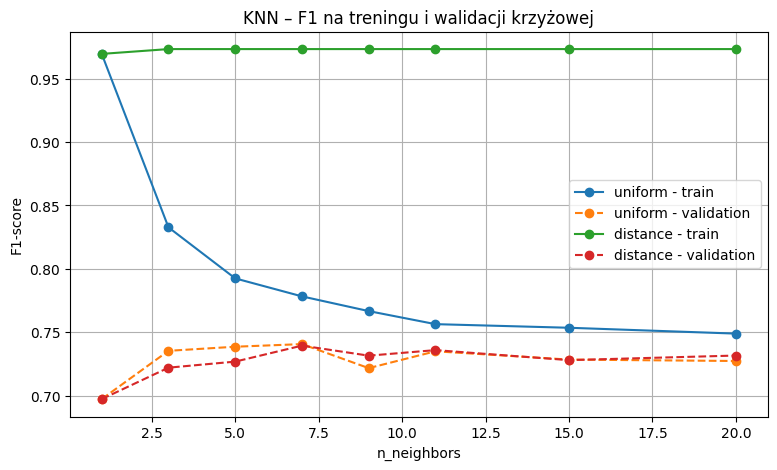

In [30]:
knn_cv_results = pd.DataFrame(knn_grid.cv_results_)

knn_cv_results[
    [
        'param_knn__n_neighbors',
        'param_knn__weights',
        'mean_train_score',
        'mean_test_score',
        'std_test_score'
    ]
].sort_values('mean_test_score', ascending=False)

plt.figure(figsize=(9, 5))

for weight in ['uniform', 'distance']:
    data = knn_cv_results[
        knn_cv_results['param_knn__weights'] == weight
    ].sort_values('param_knn__n_neighbors')

    plt.plot(
        data['param_knn__n_neighbors'],
        data['mean_train_score'],
        marker='o',
        label=f'{weight} - train'
    )

    plt.plot(
        data['param_knn__n_neighbors'],
        data['mean_test_score'],
        marker='o',
        linestyle='--',
        label=f'{weight} - validation'
    )

plt.xlabel('n_neighbors')
plt.ylabel('F1-score')
plt.title('KNN – F1 na treningu i walidacji krzyżowej')
plt.legend()
plt.grid(True)
plt.show()

**Decision Tree**

Dla drzewa decyzyjnego zbadano wpływ `max_depth` oraz `min_samples_split`.

`max_depth` ogranicza maksymalną głębokość drzewa, natomiast `min_samples_split` określa minimalną liczbę próbek wymaganą do wykonania kolejnego podziału. Parametry te mają szczególne znaczenie w tym przypadku, ponieważ początkowy model ten jest podatny na przeuczenie.

In [31]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree_param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20]
}

tree_grid = GridSearchCV(
    estimator=tree,
    param_grid=tree_param_grid,
    scoring='f1',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Najlepsze parametry Decision Tree:")
print(tree_grid.best_params_)

print("\nNajlepszy F1 na walidacji:")
print(round(tree_grid.best_score_, 4))

Najlepsze parametry Decision Tree:
{'max_depth': 3, 'min_samples_split': 2}

Najlepszy F1 na walidacji:
0.7287


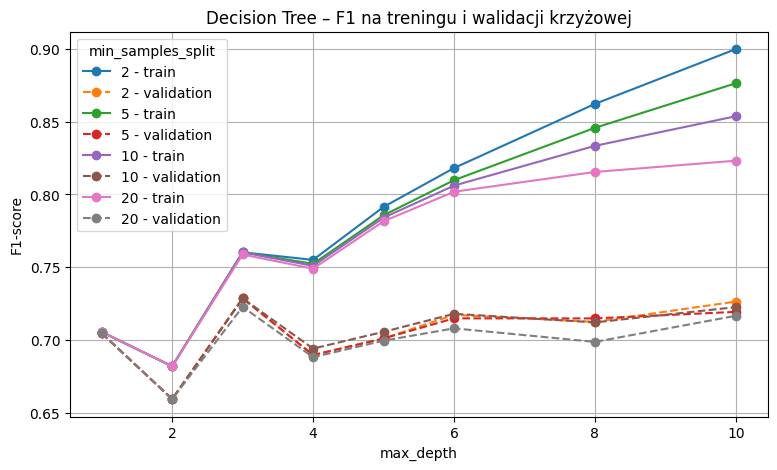

In [32]:
tree_cv_results = pd.DataFrame(tree_grid.cv_results_)

tree_cv_results[
    [
        'param_max_depth',
        'param_min_samples_split',
        'mean_train_score',
        'mean_test_score',
        'std_test_score'
    ]
].sort_values('mean_test_score', ascending=False)

plt.figure(figsize=(9, 5))

for min_split in [2, 5, 10, 20]:
    data = tree_cv_results[
        tree_cv_results['param_min_samples_split'] == min_split
    ].sort_values('param_max_depth')

    plt.plot(
        data['param_max_depth'],
        data['mean_train_score'],
        marker='o',
        label=f'{min_split} - train'
    )

    plt.plot(
        data['param_max_depth'],
        data['mean_test_score'],
        marker='o',
        linestyle='--',
        label=f'{min_split} - validation'
    )

plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('Decision Tree – F1 na treningu i walidacji krzyżowej')
plt.legend(title='min_samples_split')
plt.grid(True)
plt.show()

## Testy końcowe i podsumowanie



Po zakończeniu wyboru hiperparametrów modele zostaną ocenione na odłożonym wcześniej zbiorze testowym. Jest to jednorazowa, końcowa ocena jakości modeli na danych, które nie były wykorzystywane ani do trenowania, ani do wyboru hiperparametrów.

In [33]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

dummy_results = evaluate_model(
    dummy,
    X_train,
    y_train,
    X_test,
    y_test
)

best_knn = knn_grid.best_estimator_
best_tree = tree_grid.best_estimator_

best_knn_results = evaluate_model(
    best_knn,
    X_train,
    y_train,
    X_test,
    y_test
)

best_tree_results = evaluate_model(
    best_tree,
    X_train,
    y_train,
    X_test,
    y_test
)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Porównanie modeli**

In [34]:
comparison_df = pd.DataFrame({
    'Dummy': dummy_results,
    'KNN': best_knn_results,
    'Decision Tree': best_tree_results
}).T

comparison_df

,Train accuracy,Test accuracy,Train F1,Test F1,Test precision,Test recall
Dummy,0.6236,0.5866,0.0000,0.0000,0.0000,0.0000
KNN,0.8455,0.7933,0.7817,0.7413,0.7681,0.7162
Decision Tree,0.8301,0.7933,0.7613,0.7338,0.7846,0.6892


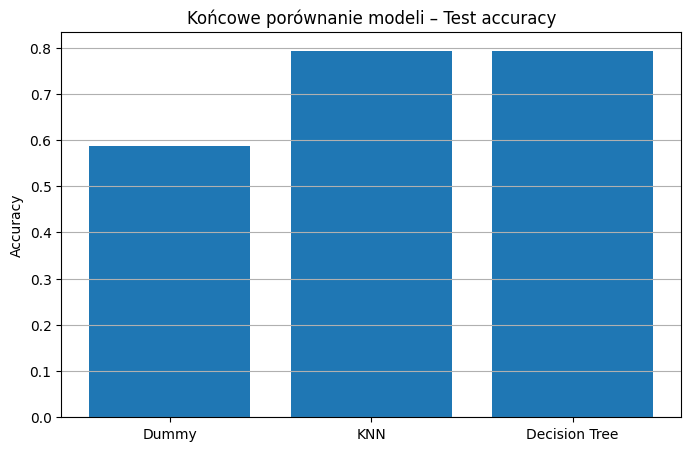

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df.index,
    comparison_df['Test accuracy']
)

plt.ylabel('Accuracy')
plt.title('Końcowe porównanie modeli – Test accuracy')
plt.grid(axis='y')

plt.show()

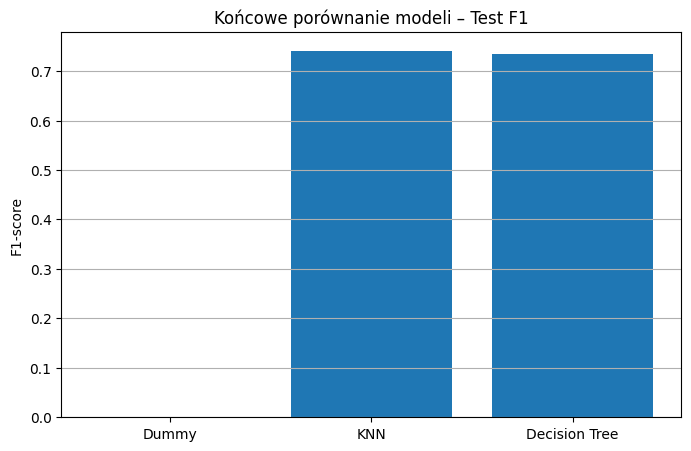

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df.index,
    comparison_df['Test F1']
)

plt.ylabel('F1-score')
plt.title('Końcowe porównanie modeli – Test F1')
plt.grid(axis='y')

plt.show()

**Wnioski końcowe**

Hiperparametry zostały dobrane za pomocą walidacji krzyżowej na zbiorze treningowym, a zbiór testowy został użyty dopiero do końcowej oceny. Dzięki podziałowi danych przed uzupełnianiem braków oraz odpowiedniemu przetwarzaniu danych ograniczono ryzyko wycieku danych między zbiorem treningowym i testowym. Najlepsze wyniki uzyskano dla KNN z `n_neighbors=7` i `weights='distance'`, natomiast dla Decision Tree wybrano `max_depth=5` i `min_samples_split=10`.

Dummy Classifier osiągnął accuracy 0.5866, ale F1 wyniósł 0, ponieważ zawsze przewiduje najczęściej występującą klasę. Dlatego sam F1 nie jest tutaj dobrym punktem odniesienia.

KNN i Decision Tree osiągnęły takie samo accuracy na teście (0.7933). KNN miał jednak trochę wyższy F1 (0.7413 vs 0.7338), więc ostatecznie uznaję go za trochę lepszy model.

Oba modele wypadły wyraźnie lepiej od Dummy Classifiera, więc nauczyły się zależności pozwalających przewidywać przeżycie pasażerów.